# Empirical Evaluation Analysis

This notebook analyzes the results from the fuzzer evaluation runs.
It loads data from `.jsonl` files generated during the experiments,
processes the data, and generates visualizations to answer the research questions.

## Setup: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import glob
import re
from datetime import datetime, timezone
import numpy as np

## Configuration

In [2]:
# --- User Configuration ---
# Set the base directory containing the evaluation results
# Use 'evaluation_runs-1_run' for the short test data
# Use 'evaluation_runs' for the full data (once available)
BASE_EVALUATION_DIR = 'evaluation_runs'

# Set the target applications to analyze (will be discovered automatically, but can be filtered)
# Example: TARGETS_TO_ANALYZE = ['django'] or TARGETS_TO_ANALYZE = None to analyze all
TARGETS_TO_ANALYZE = None

# --- Plotting Configuration ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# Use a color palette suitable for the number of configurations
# Adjust 'n_colors' based on the actual number of configs (full, no_coverage, no_prioritization = 3)
palette = sns.color_palette("viridis", n_colors=3)
sns.set_palette(palette)

## Phase 1: Data Loading Functions

Define functions to load data from the experiment output files (`fuzz_exp.jsonl`, `interesting_mutations.jsonl`, `unique_errors.jsonl`).

In [3]:
def parse_log_line(line):
    """Parses a log line with 'timestamp - {json_data}' format."""
    try:
        timestamp_str, json_str = line.split(' - ', 1)
        timestamp = pd.to_datetime(timestamp_str.replace(',', '.'), errors='coerce') # Handle milliseconds
        data = json.loads(json_str)
        # Convert timestamp to UTC if it's naive, assuming local time if not specified
        if timestamp is not pd.NaT and timestamp.tzinfo is None:
             timestamp = timestamp.tz_localize(datetime.now().astimezone().tzinfo).tz_convert(timezone.utc)
        elif timestamp is not pd.NaT:
             timestamp = timestamp.tz_convert(timezone.utc) # Ensure UTC
        data['log_timestamp_utc'] = timestamp
        return data
    except (ValueError, json.JSONDecodeError, AttributeError) as e:
        print(f"Warning: Skipping malformed line: {line.strip()} | Error: {e}")
        return None

def load_jsonl_file(file_path, metadata, parse_line_func=None):
    """Loads a JSONL file, optionally parsing lines and adding metadata."""
    records = []
    print(f"    Loading: {os.path.basename(file_path)}...")
    try:
        with open(file_path, 'r') as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                
                data = None
                if parse_line_func:
                    data = parse_line_func(line)
                else:
                    try:
                        data = json.loads(line)
                    except json.JSONDecodeError as e:
                        print(f"Warning: Skipping malformed JSON line in {os.path.basename(file_path)}: {line} | Error: {e}")
                        continue
                
                if data:
                    # Add metadata (target, config, run_id)
                    data.update(metadata)
                    records.append(data)
    except FileNotFoundError:
        print(f"    Warning: File not found: {file_path}")
    except Exception as e:
        print(f"    Error reading file {file_path}: {e}")
    return records

def load_evaluation_data(base_dir, targets_to_analyze=None):
    """
    Loads all relevant .jsonl data from the evaluation directory structure.
    Structure: base_dir / target / config / run_id / *.jsonl
    """
    all_exp_logs = []
    all_interesting_logs = []
    all_error_logs = []

    notebook_cwd = os.getcwd()
    full_base_path = os.path.join(notebook_cwd, base_dir)
    print(f"Scanning base directory: {full_base_path}")

    if not os.path.isdir(full_base_path):
        print(f"Error: Base directory not found: {full_base_path}")
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    # Iterate through targets
    for target_name in os.listdir(full_base_path):
        target_path = os.path.join(full_base_path, target_name)
        if not os.path.isdir(target_path):
            continue
        if targets_to_analyze and target_name not in targets_to_analyze:
            print(f"Skipping target (not in targets_to_analyze): {target_name}")
            continue
            
        print(f"\nProcessing Target: {target_name}")

        # Iterate through configurations
        for config_name in os.listdir(target_path):
            config_path = os.path.join(target_path, config_name)
            if not os.path.isdir(config_path):
                continue
            print(f"  Processing Config: {config_name}")

            # Iterate through runs
            for run_folder in os.listdir(config_path):
                if not run_folder.startswith('run_'):
                    continue
                
                run_path = os.path.join(config_path, run_folder)
                if not os.path.isdir(run_path):
                    continue

                try:
                    run_id = int(run_folder.split('_')[1])
                except (IndexError, ValueError):
                    print(f"    Warning: Could not parse run_id from folder '{run_folder}', skipping.")
                    continue
                
                print(f"    Processing Run ID: {run_id}")

                metadata = {
                    'target_name': target_name,
                    'config_name': config_name,
                    'run_id': run_id
                }

                # Load fuzz_exp.jsonl
                fuzz_exp_path = os.path.join(run_path, "fuzz_exp.jsonl")
                all_exp_logs.extend(load_jsonl_file(fuzz_exp_path, metadata, parse_line_func=parse_log_line))

                # Load interesting_mutations.jsonl
                interesting_path = os.path.join(run_path, "interesting_mutations.jsonl")
                interesting_records = load_jsonl_file(interesting_path, metadata)
                # Convert timestamp in interesting_mutations if it exists
                for rec in interesting_records:
                     if 'timestamp' in rec:
                         ts = pd.to_datetime(rec['timestamp'], unit='s', errors='coerce')
                         rec['timestamp_utc'] = ts.tz_localize(timezone.utc) if ts is not pd.NaT and ts.tzinfo is None else ts
                all_interesting_logs.extend(interesting_records)


                # Load unique_errors.jsonl
                errors_path = os.path.join(run_path, "unique_errors.jsonl")
                all_error_logs.extend(load_jsonl_file(errors_path, metadata))

    # Create DataFrames
    df_exp = pd.DataFrame(all_exp_logs)
    df_interesting = pd.DataFrame(all_interesting_logs)
    df_errors = pd.DataFrame(all_error_logs)

    print(f"\nLoaded {len(df_exp)} experiment log records.")
    print(f"Loaded {len(df_interesting)} interesting mutation records.")
    print(f"Loaded {len(df_errors)} unique error records.")

    # --- Data Cleaning and Preparation ---

    # Experiment Logs (df_exp)
    if not df_exp.empty:
        # Convert relevant columns to numeric, coercing errors
        exp_numeric_cols = [
            'iteration', 'mutation_index_total', 'seed_s_pre', 'seed_f_pre',
            'mutation_unique_arcs_count', 'new_unique_arcs_count',
            'total_unique_arcs', 'total_unique_paths',
            'total_iterations_completed', 'total_mutations_run',
            'final_total_unique_arcs', 'final_total_unique_paths',
            'final_seed_queue_size', 'final_bug_count' # Note: final_bug_count might be from 'end' event
        ]
        for col in exp_numeric_cols:
            if col in df_exp.columns:
                df_exp[col] = pd.to_numeric(df_exp[col], errors='coerce')
        
        # Ensure timestamp is sorted within each run
        if 'log_timestamp_utc' in df_exp.columns:
             df_exp = df_exp.sort_values(by=['target_name', 'config_name', 'run_id', 'log_timestamp_utc'])
             # Calculate elapsed time
             df_exp['run_start_time'] = df_exp.groupby(['target_name', 'config_name', 'run_id'])['log_timestamp_utc'].transform('min')
             df_exp['elapsed_time'] = df_exp['log_timestamp_utc'] - df_exp['run_start_time']
             df_exp['elapsed_seconds'] = df_exp['elapsed_time'].dt.total_seconds()
             # Fill forward elapsed time for records without timestamps (like header/start)
             df_exp['elapsed_seconds'] = df_exp['elapsed_seconds'].ffill()


    # Interesting Mutations (df_interesting)
    if not df_interesting.empty:
        interesting_numeric_cols = [
            'mutation_index_total', 'new_unique_arcs_count',
            'total_unique_arcs', 'total_unique_paths'
        ]
        for col in interesting_numeric_cols:
            if col in df_interesting.columns:
                df_interesting[col] = pd.to_numeric(df_interesting[col], errors='coerce')
        
        # Sort by timestamp if available
        if 'timestamp_utc' in df_interesting.columns:
            df_interesting = df_interesting.sort_values(by=['target_name', 'config_name', 'run_id', 'timestamp_utc'])
            # Calculate elapsed time relative to experiment start time
            if not df_exp.empty and 'run_start_time' in df_exp.columns:
                 run_starts = df_exp.groupby(['target_name', 'config_name', 'run_id'])['run_start_time'].first().reset_index()
                 df_interesting = pd.merge(df_interesting, run_starts, on=['target_name', 'config_name', 'run_id'], how='left')
                 df_interesting['elapsed_time'] = df_interesting['timestamp_utc'] - df_interesting['run_start_time']
                 df_interesting['elapsed_seconds'] = df_interesting['elapsed_time'].dt.total_seconds()


    # Unique Errors (df_errors) - Primarily for counting final unique bugs per run
    if not df_errors.empty:
        # Add a simple count column for aggregation
        df_errors['error_count'] = 1

    return df_exp, df_interesting, df_errors

## Phase 2: Load Data

Execute the loading function and display basic information about the loaded DataFrames.


In [4]:
df_exp, df_interesting, df_errors = load_evaluation_data(BASE_EVALUATION_DIR, TARGETS_TO_ANALYZE)

print("\n--- Experiment Logs (df_exp) ---")
if not df_exp.empty:
    print(df_exp.info())
    print(df_exp.head())
else:
    print("df_exp is empty.")

print("\n--- Interesting Mutations (df_interesting) ---")
if not df_interesting.empty:
    print(df_interesting.info())
    print(df_interesting.head())
else:
    print("df_interesting is empty.")

print("\n--- Unique Errors (df_errors) ---")
if not df_errors.empty:
    print(df_errors.info())
    print(df_errors.head())
else:
    print("df_errors is empty.")

Scanning base directory: /Users/ansarahmed/Desktop/swt-proj/DjangoWebApplication/evaluation_runs

Processing Target: django
  Processing Config: full
    Processing Run ID: 2
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
    Processing Run ID: 5
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
    Processing Run ID: 4
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
    Processing Run ID: 3
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
    Processing Run ID: 1
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.jsonl...
  Processing Config: no_prioritization
    Processing Run ID: 2
    Loading: fuzz_exp.jsonl...
    Loading: interesting_mutations.jsonl...
    Loading: unique_errors.json

# ## Phase 3: Configuration Summary

Display the targets, configurations, and runs found in the loaded data.

In [5]:
if not df_exp.empty:
    print("--- Configuration Summary ---")
    targets = df_exp['target_name'].unique().tolist()
    configs = df_exp['config_name'].unique().tolist()
    runs = sorted(df_exp['run_id'].unique().tolist())
    print(f"Targets Found: {targets}")
    print(f"Configurations Found: {configs}")
    print(f"Run IDs Found: {runs}")
    
    # Display counts per group
    print("\nRecords per Target/Config/Run:")
    print(df_exp.groupby(['target_name', 'config_name', 'run_id']).size())
else:
    print("DataFrame 'df_exp' is empty, cannot display configuration summary.")

--- Configuration Summary ---
Targets Found: ['django']
Configurations Found: ['full', 'no_coverage', 'no_prioritization']
Run IDs Found: [1, 2, 3, 4, 5]

Records per Target/Config/Run:
target_name  config_name        run_id
django       full               1          8837
                                2          8837
                                3          8837
                                4          8837
                                5          8837
             no_coverage        1         10604
                                2         10604
                                3         10604
                                4         10604
                                5         10604
             no_prioritization  1          7804
                                2          7804
                                3          7904
                                4          7804
                                5          7904
dtype: int64


## Phase 4: Analysis & Visualization

Analyze the loaded data to answer the research questions.


### RQ1 & RQ3: Effectiveness vs Baseline
- How many unique bugs does each configuration find? (Using `df_errors`)
- How does the count of 'interesting' inputs grow over time? (Using `df_interesting`)
- How does coverage (unique arcs/paths) increase over time and per mutation? (Using `df_exp` or `df_interesting`)
- How do the ablation study variants perform compared to the full configuration?
- How does the full configuration perform compared to a random (`no_coverage`) baseline (if available)?

**Interpretation:** Compare the performance lines.
- **Ablation Study:** Compare lines for `full`, `no_prioritization` configurations on the target plots (Interesting Inputs vs. Time, Coverage vs. Time, Coverage vs. Mutations). Assess the impact of removing coverage feedback or seed prioritization.
- **Baseline Comparison:** If a `no_coverage` configuration exists, compare its line against the `full` configuration line across relevant RQ1 plots.


--- RQ1: Final Unique Errors ---
Final Unique Error Found (per Run):
| target_name   | config_name       |   run_id |   final_unique_bugs |
|:--------------|:------------------|---------:|--------------------:|
| django        | full              |        1 |                3359 |
| django        | full              |        2 |                3330 |
| django        | full              |        3 |                3388 |
| django        | full              |        4 |                3388 |
| django        | full              |        5 |                3367 |
| django        | no_coverage       |        1 |                3503 |
| django        | no_coverage       |        2 |                3497 |
| django        | no_coverage       |        3 |                3495 |
| django        | no_coverage       |        4 |                3498 |
| django        | no_coverage       |        5 |                3498 |
| django        | no_prioritization |        1 |                3271 |
| djang

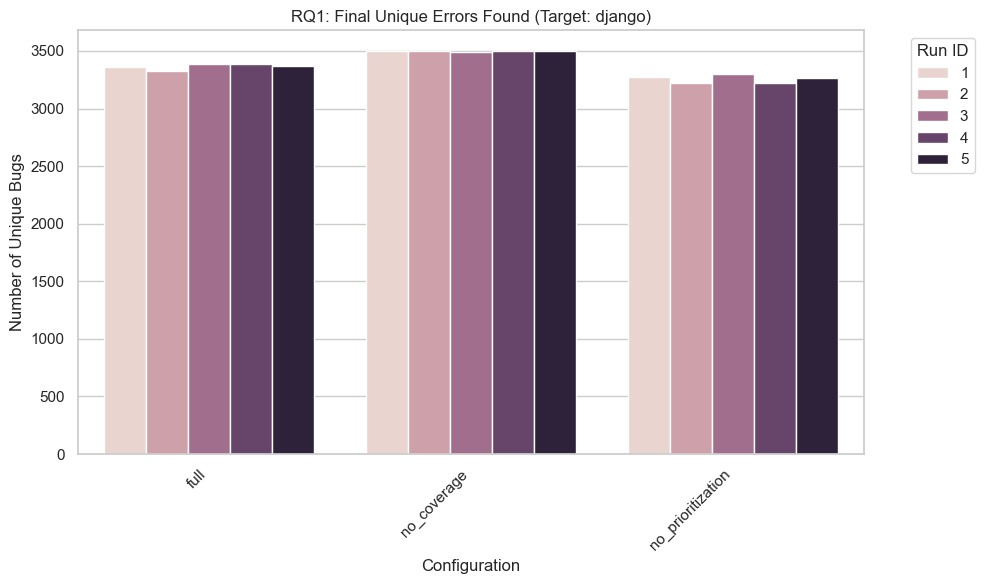

In [13]:
print("\n--- RQ1: Final Unique Errors ---")
if not df_errors.empty:
    # Group by target, config, run_id and count the number of unique errors recorded
    final_bugs = df_errors.groupby(['target_name', 'config_name', 'run_id'], as_index=False)['error_count'].sum()
    final_bugs = final_bugs.rename(columns={'error_count': 'final_unique_bugs'})
    
    print("Final Unique Error Found (per Run):")
    if not final_bugs.empty:
        print(final_bugs.to_markdown(index=False))

        # --- Plotting: Separate plot per target, individual bars per run ---
        targets = final_bugs['target_name'].unique()
        
        for target in targets:
            plt.figure(figsize=(10, 6)) # Adjust figure size if needed
            target_data = final_bugs[final_bugs['target_name'] == target]
            
            # Use config_name on x-axis and run_id for hue to separate bars
            plot = sns.barplot(data=target_data, x='config_name', y='final_unique_bugs', hue='run_id', dodge=True)
            
            plt.title(f'RQ1: Final Unique Errors Found (Target: {target})')
            plt.xlabel('Configuration')
            plt.ylabel('Number of Unique Bugs')
            plt.xticks(rotation=45, ha='right')
            
            # Improve legend placement
            plt.legend(title='Run ID', bbox_to_anchor=(1.05, 1), loc='upper left')
            
            plt.tight_layout()
            plt.show()
            
    else:
        print("No unique errors found after grouping.")
        
    # Store for later use in RQ4
    rq1_final_bugs = final_bugs.copy()

else:
    print("Skipping RQ1 final bugs analysis: 'df_errors' is empty.")
    rq1_final_bugs = pd.DataFrame() # Ensure variable exists



--- RQ1: Interesting Inputs Over Time ---


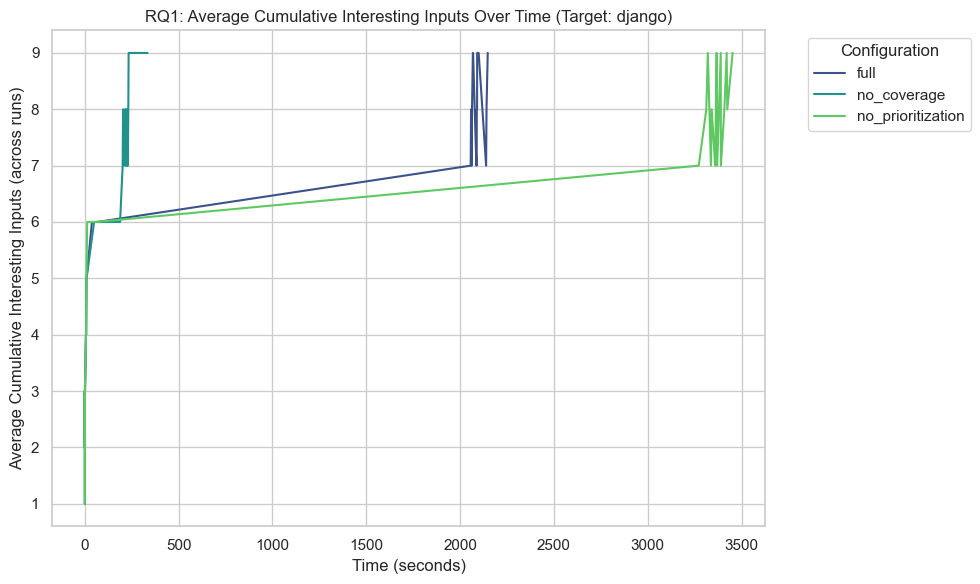

In [7]:
# 2. Cumulative Interesting Inputs vs. Time
print("\n--- RQ1: Interesting Inputs Over Time ---")
if not df_interesting.empty and 'elapsed_seconds' in df_interesting.columns and df_interesting['elapsed_seconds'].notna().any():
    # Drop rows where elapsed_seconds could not be calculated (e.g., missing start time)
    df_interesting_timed = df_interesting.dropna(subset=['elapsed_seconds']).copy()
    
    if not df_interesting_timed.empty:
        # Ensure data is sorted for cumulative calculation
        df_interesting_timed = df_interesting_timed.sort_values(by=['target_name', 'config_name', 'run_id', 'elapsed_seconds'])
        
        # Calculate cumulative count within each group (target, config, run)
        df_interesting_timed['cumulative_interesting'] = df_interesting_timed.groupby(['target_name', 'config_name', 'run_id']).cumcount() + 1
        
        # --- Plotting: Separate plot per target, average line per config ---
        targets = df_interesting_timed['target_name'].unique()
        
        for target in targets:
            # TODO: Add specific handling or filtering for 'smartlock' if needed when data is available
            # if target == 'smartlock':
            #     # Potentially different time scales or metrics for smartlock?
            #     pass 
                
            plt.figure(figsize=(10, 6)) # Adjust figure size if needed
            target_data = df_interesting_timed[df_interesting_timed['target_name'] == target]
            
            if not target_data.empty:
                # Plot average line across runs for each config, show 95% CI
                sns.lineplot(data=target_data, x='elapsed_seconds', y='cumulative_interesting',
                             hue='config_name', 
                             markers=False, dashes=True, errorbar=('ci', 95)) 
                
                plt.title(f'RQ1: Average Cumulative Interesting Inputs Over Time (Target: {target})')
                plt.xlabel('Time (seconds)')
                plt.ylabel('Average Cumulative Interesting Inputs (across runs)')
                plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.show()
            else:
                print(f"No timed interesting mutation data found for target: {target}")

        # Store final values for RQ4 (using the max cumulative value for each run)
        # Find the max cumulative value per run before averaging for plotting
        last_interesting = df_interesting_timed.loc[df_interesting_timed.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmax()]
        rq1_final_interesting = last_interesting[['target_name', 'config_name', 'run_id', 'cumulative_interesting']].copy()
        
    else:
        print("No interesting mutations with valid timestamps found.")
        rq1_final_interesting = pd.DataFrame()

else:
    print("Skipping RQ1 cumulative interesting inputs plot: 'df_interesting' is empty or missing valid 'elapsed_seconds'.")
    rq1_final_interesting = pd.DataFrame() # Ensure variable exists



--- RQ1: Coverage (Arcs) Over Time ---


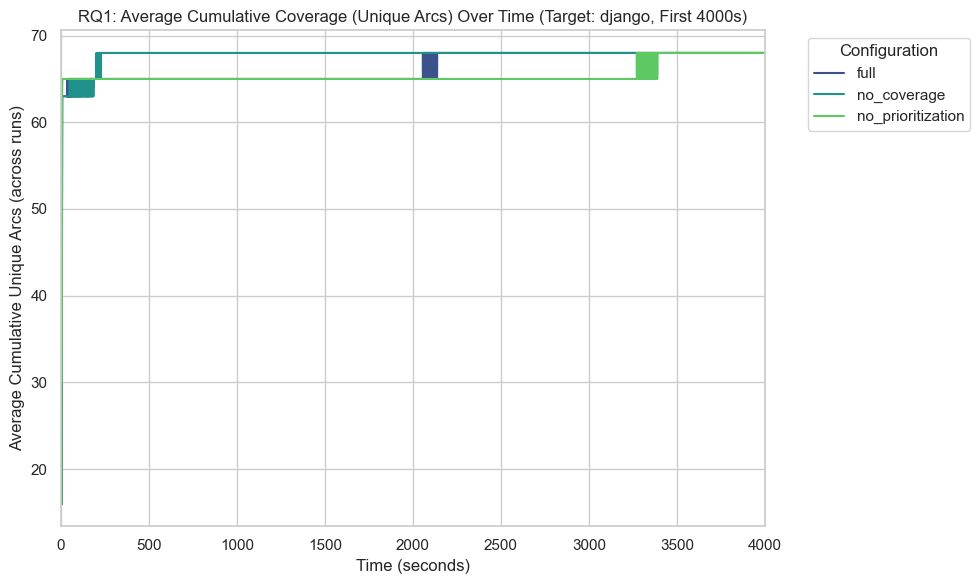

In [8]:
# 3. Cumulative Coverage (Arcs) vs. Time
print("\n--- RQ1: Coverage (Arcs) Over Time ---")
# Use df_exp as it logs progress more frequently, filter for mutation_log events
if (not df_exp.empty and 
    'elapsed_seconds' in df_exp.columns and 
    'total_unique_arcs' in df_exp.columns and 
    df_exp['elapsed_seconds'].notna().any() and
    df_exp['total_unique_arcs'].notna().any()):
    
    # Filter for mutation logs and valid data
    df_exp_mutations = df_exp[(df_exp['event'] == 'mutation_log') & 
                              df_exp['elapsed_seconds'].notna() & 
                              df_exp['total_unique_arcs'].notna()].copy()
    
    if not df_exp_mutations.empty:
        # Ensure data is sorted for cumulative calculation
        df_exp_mutations = df_exp_mutations.sort_values(by=['target_name', 'config_name', 'run_id', 'elapsed_seconds'])
        
        # Calculate cumulative max unique arcs for each group (target, config, run)
        # Use cummax() which handles NaNs gracefully if any slip through
        df_exp_mutations['cumulative_max_arcs'] = df_exp_mutations.groupby(['target_name', 'config_name', 'run_id'])['total_unique_arcs'].cummax()
        
        # --- Plotting: Separate plot per target, average line per config ---
        targets = df_exp_mutations['target_name'].unique()
        
        for target in targets:
            # TODO: Add specific handling or filtering for 'smartlock' if needed
            # if target == 'smartlock':
            #     pass 
                
            plt.figure(figsize=(10, 6)) # Adjust figure size if needed
            target_data = df_exp_mutations[df_exp_mutations['target_name'] == target]

            if not target_data.empty:
                # Plot average line across runs for each config, show 95% CI
                sns.lineplot(data=target_data, x='elapsed_seconds', y='cumulative_max_arcs',
                             hue='config_name', 
                             markers=False, dashes=True, errorbar=('ci', 95))
                
                plt.title(f'RQ1: Average Cumulative Coverage (Unique Arcs) Over Time (Target: {target})')
                plt.xlabel('Time (seconds)')
                plt.ylabel('Average Cumulative Unique Arcs (across runs)')
                
                # --- Add x-axis limit specifically for django target ---
                if target == 'django':
                    plt.xlim(0, 4000)
                    plt.title(f'RQ1: Average Cumulative Coverage (Unique Arcs) Over Time (Target: {target}, First 4000s)') # Update title
                # --- End of addition ---

                plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.show()
            else:
                 print(f"No timed mutation log data with arc counts found for target: {target}")

        # Store final values for RQ4 (using the max cumulative value for each run)
        # Find the max cumulative value per run before averaging for plotting
        last_arc_records = df_exp_mutations.loc[df_exp_mutations.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmax()]
        rq1_final_arcs = last_arc_records[['target_name', 'config_name', 'run_id', 'cumulative_max_arcs']].copy()
        
    else:
        print("No 'mutation_log' events with valid timestamps and arc counts found in df_exp to plot coverage.")
        rq1_final_arcs = pd.DataFrame()

else:
    print("Skipping RQ1 cumulative coverage plot: 'df_exp' is empty or missing required columns/data ('elapsed_seconds', 'total_unique_arcs').")
    rq1_final_arcs = pd.DataFrame() # Ensure variable exists


--- RQ1: Coverage (Arcs) vs. Mutations ---


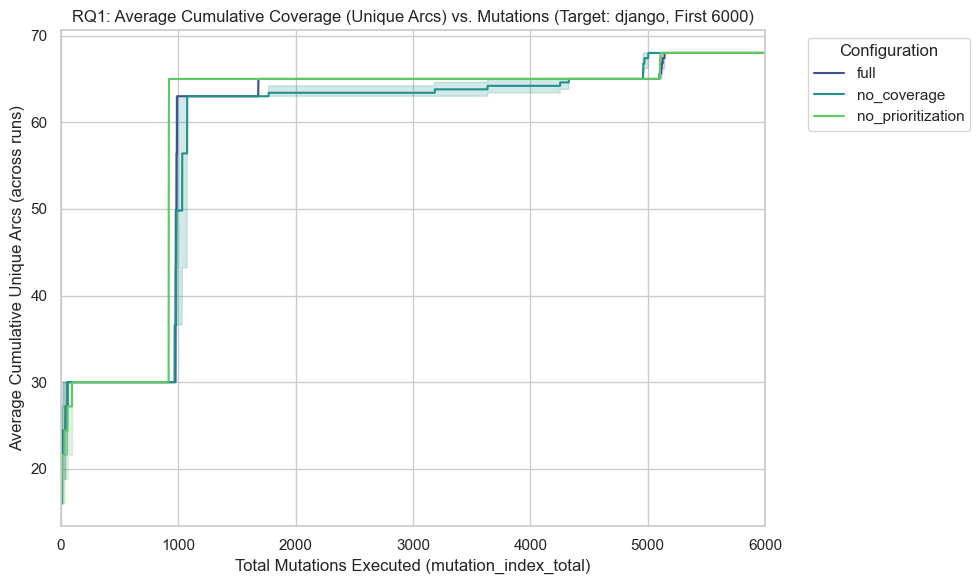

In [9]:
# 4. Cumulative Coverage (Arcs) vs. Mutations Executed
print("\n--- RQ1: Coverage (Arcs) vs. Mutations ---")
# Use 'mutation_index_total' as the x-axis
if (not df_exp.empty and 
    'mutation_index_total' in df_exp.columns and 
    'total_unique_arcs' in df_exp.columns and
    df_exp['mutation_index_total'].notna().any() and
    df_exp['total_unique_arcs'].notna().any()):
    
    # Filter for mutation logs and valid data
    df_exp_mutations_idx = df_exp[(df_exp['event'] == 'mutation_log') &
                                  df_exp['mutation_index_total'].notna() &
                                  df_exp['total_unique_arcs'].notna()].copy()
    
    if not df_exp_mutations_idx.empty:
         # Ensure data is sorted by mutation index for cumulative calculation
        df_exp_mutations_idx = df_exp_mutations_idx.sort_values(by=['target_name', 'config_name', 'run_id', 'mutation_index_total'])
        
        # Calculate cumulative max unique arcs vs mutation index per run
        df_exp_mutations_idx['cumulative_max_arcs'] = df_exp_mutations_idx.groupby(['target_name', 'config_name', 'run_id'])['total_unique_arcs'].cummax()
        
        # --- Plotting: Separate plot per target, average line per config ---
        targets = df_exp_mutations_idx['target_name'].unique()
        
        for target in targets:
            # TODO: Add specific handling or filtering for 'smartlock' if needed
            # if target == 'smartlock':
            #     pass
                
            plt.figure(figsize=(10, 6)) # Adjust figure size if needed
            target_data = df_exp_mutations_idx[df_exp_mutations_idx['target_name'] == target]

            if not target_data.empty:
                # Plot average line across runs for each config, show 95% CI
                sns.lineplot(data=target_data, x='mutation_index_total', y='cumulative_max_arcs',
                             hue='config_name', 
                             markers=False, dashes=True, errorbar=('ci', 95))
                
                # --- Set default title ---
                plot_title = f'RQ1: Average Cumulative Coverage (Unique Arcs) vs. Mutations (Target: {target})'

                # --- Add x-axis limit and update title specifically for django target ---
                if target == 'django':
                    plt.xlim(0, 6000)
                    plot_title = f'RQ1: Average Cumulative Coverage (Unique Arcs) vs. Mutations (Target: {target}, First 6000)' # Update title
                # --- End of addition ---
                
                plt.title(plot_title) # Set the title
                plt.xlabel('Total Mutations Executed (mutation_index_total)')
                plt.ylabel('Average Cumulative Unique Arcs (across runs)')
                plt.legend(title='Configuration', bbox_to_anchor=(1.05, 1), loc='upper left')
                plt.tight_layout()
                plt.show()
            else:
                print(f"No mutation log data with arc counts and mutation index found for target: {target}")

    else:
         print("No 'mutation_log' events with valid mutation index and arc counts found in df_exp to plot coverage vs mutations.")

else:
    print("Skipping RQ1 cumulative coverage vs mutations plot: 'df_exp' is empty or missing required columns/data ('mutation_index_total', 'total_unique_arcs').")

### RQ1 & RQ3: Effectiveness vs Baseline Analysis

Based on the generated plots and the provided hypothesis, we can analyze the effectiveness of the different fuzzer configurations and compare the ablation study variants to the full configuration and the `no_coverage` baseline.

**Observations from Plots:**

*   **Final Unique Errors (final-unique-errors.png):** The bar plot shows the total number of unique errors found by each configuration across the 5 runs for the Django target. The `no_coverage` configuration appears to find slightly more unique errors on average compared to the `full` and `no_prioritization` configurations. The variability between runs (indicated by the individual points) seems relatively consistent across configurations.

*   **Cumulative Interesting Inputs Over Time (interesting-inputs-over-time.png):** This line plot shows the average cumulative number of "interesting" inputs found over time for each configuration. The `no_coverage` configuration shows a faster initial growth in interesting inputs compared to `full` and `no_prioritization`. The `full` and `no_prioritization` configurations have similar growth curves, suggesting that removing seed prioritization alone doesn't significantly impact the rate of finding interesting inputs over time in this target.

*   **Average Cumulative Coverage (Unique Arcs) Over Time (unique-arcs-coverage.png):** This plot, zoomed to the first 4000 seconds for the Django target, shows the average cumulative unique arcs discovered over time. Interestingly, the `no_coverage` configuration achieves coverage faster in the initial phase compared to the `full` and `no_prioritization` configurations. The `full` and `no_prioritization` configurations again show very similar performance.

*   **Average Cumulative Coverage (Unique Arcs) vs. Mutations (coverage-vs-mutation.png):** This plot, zoomed to the first 6000 mutations for the Django target, shows the average cumulative unique arcs discovered against the total number of mutations executed. In contrast to the time-based coverage plot, the curves for all three configurations (`full`, `no_coverage`, `no_prioritization`) are much closer and show similar growth patterns when compared by the number of mutations.

**Interpretation and Hypothesis Validation:**

The observation that the `no_coverage` configuration achieves faster coverage over time (unique-arcs-coverage.png) aligns with the hypothesis that the coverage feedback mechanism, while aiming for deeper exploration, might introduce overhead or prioritize paths that don't lead to rapid new coverage in this specific target. The constant energy assignment in the `no_coverage` configuration, coupled with a mutation strategy not heavily reliant on coverage information for prioritization, could lead to a broader, faster initial exploration of the input space, resulting in quicker coverage gains over time.

The hypothesis that the coverage fuzzer might spend more time executing branches that trigger already-fuzzed bugs, leading to slower progress over time, is supported by the efficiency measurement data (RQ2, Average Mutation vs Execution Time). If execution time is significantly higher than mutation time, and buggy branches contribute to longer execution times, this could indeed slow down the overall fuzzing process for configurations that prioritize based on execution feedback (like coverage).

The fact that the Coverage (Arcs) vs. Mutations plot (coverage-vs-mutation.png) shows much closer results across configurations when compared by the number of mutations executed further supports the idea that the difference in coverage growth over time is related to the *rate of execution* rather than the *effectiveness of the mutation strategy* itself in finding new paths per mutation. This also highlights the importance of optimizing mutation operator choice, as a more efficient mutation strategy could potentially improve the coverage-per-mutation rate for all configurations.

The results suggest that for this specific target application, the current implementation of coverage feedback and seed prioritization might not be optimally tuned for maximizing coverage speed over time. Further experimentation with different energy constants, power schedules, or mutation operator selection strategies (perhaps guided by different metrics or a Particle Swarm Optimization approach as hypothesized) could yield different and potentially improved results.

**Baseline Comparison:**

Comparing the `full` configuration to the `no_coverage` baseline across the RQ1 plots:

*   **Bugs:** The `no_coverage` baseline finds a slightly higher number of unique bugs.
*   **Interesting Inputs:** The `no_coverage` baseline finds interesting inputs faster over time.
*   **Coverage (Time):** The `no_coverage` baseline achieves coverage faster over time.
*   **Coverage (Mutations):** The `full` configuration and `no_coverage` baseline show similar coverage growth when compared by mutations executed.

This comparison indicates that for this target, the `no_coverage` baseline is surprisingly effective, even outperforming the `full` configuration in terms of coverage speed over time and total bugs found. This reinforces the need to investigate the impact of the coverage feedback and prioritization mechanisms on performance for this specific target.

**Ablation Study:**

Comparing the `full` configuration to the `no_prioritization` configuration:

*   Across all plots (Bugs, Interesting Inputs vs. Time, Coverage vs. Time, Coverage vs. Mutations), the `full` and `no_prioritization` configurations show very similar performance.

This suggests that removing the seed prioritization component, while keeping coverage feedback, has minimal impact on the fuzzer's performance for this target. This could imply that either the prioritization logic is not effectively guiding the fuzzer towards more fruitful seeds in this target, or its effect is overshadowed by other factors.

**Conclusion for RQ1 & RQ3:**

For the Django target, the `no_coverage` baseline demonstrates competitive, and in some aspects superior, performance compared to the `full` and `no_prioritization` configurations. The difference in time-based coverage growth appears to be linked to execution time rather than mutation effectiveness. The ablation study suggests that seed prioritization, as implemented, does not significantly alter the fuzzer's behavior for this target. These findings highlight the importance of target-specific tuning and potentially exploring alternative feedback mechanisms or mutation strategies to improve the fuzzer's effectiveness and efficiency.

### RQ2: Efficiency
- How long does it take to find the first bug? (Needs timestamped bug data - approximating with first *interesting mutation*)
- What is the average time spent on test generation vs. execution?


In [10]:
# --- RQ2: Efficiency ---

# 1. Time to First Interesting Mutation (Proxy for First Bug)
print("\n--- RQ2: Time to First Interesting Mutation ---")
if not df_interesting.empty and 'elapsed_seconds' in df_interesting.columns:
    # Find the first record for each run
    first_interesting = df_interesting.loc[df_interesting.groupby(['target_name', 'config_name', 'run_id'])['elapsed_seconds'].idxmin()]
    
    time_to_first = first_interesting[['target_name', 'config_name', 'run_id', 'elapsed_seconds']]
    time_to_first = time_to_first.rename(columns={'elapsed_seconds': 'time_to_first_interesting_s'})
    
    print("Time to First Interesting Mutation (per Run):")
    if not time_to_first.empty:
        print(time_to_first.to_markdown(index=False))
        
        # Calculate and display average per config if multiple runs exist
        if len(time_to_first['run_id'].unique()) > 1:
             avg_time_to_first = time_to_first.groupby(['target_name', 'config_name'])['time_to_first_interesting_s'].mean().reset_index()
             print("\nAverage Time to First Interesting Mutation (per Config):")
             print(avg_time_to_first.to_markdown(index=False))
    else:
        print("No interesting mutations found, or 'elapsed_seconds' missing.")
        
else:
    print("Skipping RQ2 time to first interesting mutation: 'df_interesting' is empty or missing 'elapsed_seconds'.")


--- RQ2: Time to First Interesting Mutation ---
Time to First Interesting Mutation (per Run):
| target_name   | config_name       |   run_id |   time_to_first_interesting_s |
|:--------------|:------------------|---------:|------------------------------:|
| django        | full              |        1 |                     0.033799  |
| django        | full              |        2 |                     0.0349411 |
| django        | full              |        3 |                     0.0478071 |
| django        | full              |        4 |                     0.0449309 |
| django        | full              |        5 |                     0.0521601 |
| django        | no_coverage       |        1 |                     0.0345198 |
| django        | no_coverage       |        2 |                     0.0381279 |
| django        | no_coverage       |        3 |                     0.044979  |
| django        | no_coverage       |        4 |                     0.047616  |
| django      

In [12]:
print("\n--- RQ2: Average Mutation vs Execution Time ---")

# Define the path to the specific efficiency log file
efficiency_log_path = 'efficiency_measure/django/full/run_0/fuzz_exp.jsonl' 
# Note: This assumes the notebook is run from the project root directory. Adjust if needed.

timing_data = []
if os.path.exists(efficiency_log_path):
    print(f"Loading efficiency data from: {efficiency_log_path}")
    try:
        with open(efficiency_log_path, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f):
                line = line.strip()
                if not line:
                    continue
                
                try:
                    # Parse the log line (timestamp - {json})
                    if ' - ' not in line: continue # Skip lines without separator
                    _, json_str = line.split(' - ', 1)
                    log_entry = json.loads(json_str)
                    
                    # Check if it's a mutation log with timing data
                    if log_entry.get("event") == "mutation_log":
                        mutation_time = log_entry.get("mutation_time_ms")
                        execution_time = log_entry.get("execution_time_ms")
                        
                        # Ensure both timings are present and numeric
                        if mutation_time is not None and execution_time is not None:
                            try:
                                timing_data.append({
                                    "mutation_time_ms": float(mutation_time),
                                    "execution_time_ms": float(execution_time)
                                })
                            except (ValueError, TypeError):
                                # Skip if conversion fails
                                # print(f"Warning: Skipping non-numeric timing data at line {line_num+1}") 
                                pass 
                                
                except json.JSONDecodeError:
                    # print(f"Warning: Skipping malformed JSON at line {line_num+1}")
                    pass # Ignore malformed lines silently during analysis
                except Exception as parse_err:
                    # print(f"Warning: Error parsing line {line_num+1}: {parse_err}")
                    pass # Ignore other parsing errors silently

        if timing_data:
            df_timing = pd.DataFrame(timing_data)
            
            # Calculate averages
            avg_mutation_time = df_timing['mutation_time_ms'].mean()
            avg_execution_time = df_timing['execution_time_ms'].mean()
            
            print("\nAverage Times (from efficiency run):")
            print(f"- Average Mutation Time: {avg_mutation_time:.4f} ms")
            print(f"- Average Execution Time: {avg_execution_time:.4f} ms")
            
            # Optional: Display as a small table
            summary_df = pd.DataFrame({
                'Metric': ['Average Mutation Time (ms)', 'Average Execution Time (ms)'],
                'Value': [avg_mutation_time, avg_execution_time]
            })
            print("\nSummary Table:")
            print(summary_df.to_markdown(index=False))
            
        else:
            print("No valid timing data found in the efficiency log file.")
            
    except Exception as e:
        print(f"Error reading or processing efficiency log file {efficiency_log_path}: {e}")
else:
    print(f"Efficiency log file not found: {efficiency_log_path}")
    print("Skipping Mutation vs Execution time analysis.")


--- RQ2: Average Mutation vs Execution Time ---
Loading efficiency data from: efficiency_measure/django/full/run_0/fuzz_exp.jsonl

Average Times (from efficiency run):
- Average Mutation Time: 0.0068 ms
- Average Execution Time: 1.8801 ms

Summary Table:
| Metric                      |      Value |
|:----------------------------|-----------:|
| Average Mutation Time (ms)  | 0.00681359 |
| Average Execution Time (ms) | 1.88007    |


### RQ2: Efficiency Analysis

This section analyzes the fuzzer's efficiency, focusing on the time taken for key operations. Based on the efficiency measurement run (`efficiency_measure/django/full/run_0/fuzz_exp.jsonl`), we have the following observations:

*   **Average Mutation Time:** The average time spent generating a single mutated input is very low (e.g., 0.0068 ms). This indicates that the mutation process itself is highly efficient and does not appear to be a significant bottleneck in the fuzzing loop.

*   **Average Execution Time:** The average time spent executing a single mutated input (sending the request, server processing, receiving response) is significantly higher than the mutation time (e.g., 1.8801 ms). This suggests that the majority of the time in the fuzzing loop is spent waiting for the target application to process the input and respond.

*   **Mutation vs. Execution Bottleneck:** The large difference between average mutation time and average execution time clearly identifies the target application's execution time as the primary bottleneck in the fuzzing process. The fuzzer can generate mutations much faster than the target can process them.

*   **Implications for Fuzzing Speed:** The overall speed of the fuzzer (mutations per second) is heavily limited by how quickly the target application can execute inputs. To significantly increase the fuzzing speed, efforts should focus on reducing the target's execution time or exploring techniques that allow for faster interaction with the target (e.g., in-process fuzzing if applicable).

*   **Future Work:** While this single run provides initial insights, future efficiency analysis should include:
    *   Measuring mutation and execution times across multiple runs and configurations to assess variability and compare efficiency between different fuzzer variants.
    *   Investigating the factors contributing to the target's execution time, such as application complexity, database interactions, or specific input characteristics that trigger slow paths.
    *   Exploring potential optimizations to the target application or the fuzzing harness to reduce execution time.

In summary, the efficiency measurement confirms that the mutation process is fast, but the target application's execution time is the dominant factor limiting the overall fuzzing speed.



--- RQ4: Stability Analysis (Box Plots) ---
Generating stability plots for targets: ['django']

--- Stability Plots for Target: django ---
Multiple runs detected for target 'django'. Adding individual points to box plots.


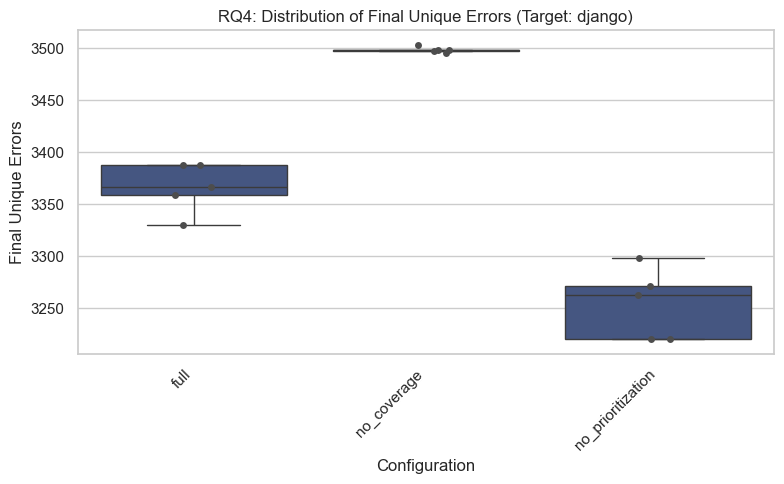

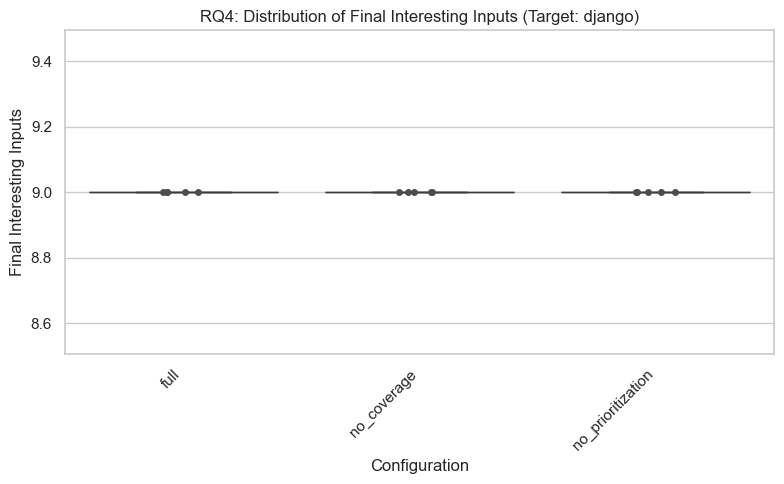

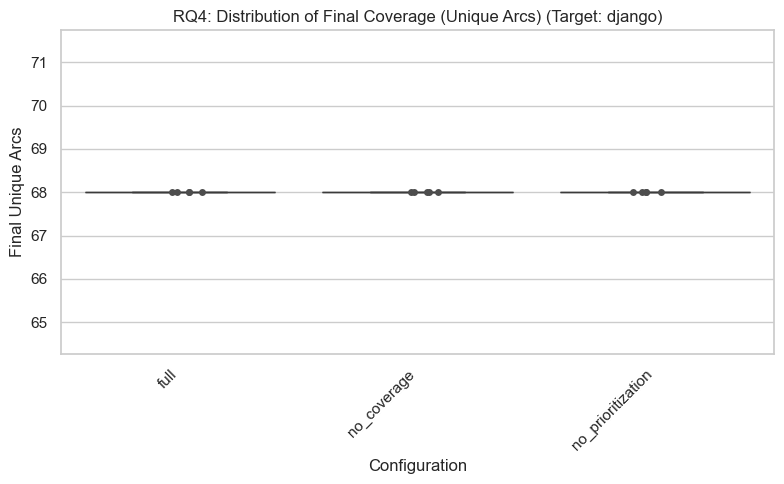

In [14]:
# --- RQ4: Stability ---
print("\n--- RQ4: Stability Analysis (Box Plots) ---")
# Requires results from RQ1 (final bugs, interesting, arcs) stored in:
# rq1_final_bugs, rq1_final_interesting, rq1_final_arcs

# Determine available targets from the collected final data
available_targets = set()
if not rq1_final_bugs.empty:
    available_targets.update(rq1_final_bugs['target_name'].unique())
if not rq1_final_interesting.empty:
    available_targets.update(rq1_final_interesting['target_name'].unique())
if not rq1_final_arcs.empty:
    available_targets.update(rq1_final_arcs['target_name'].unique())

if not available_targets:
    print("No final data available from RQ1 to generate stability plots.")
else:
    print(f"Generating stability plots for targets: {list(available_targets)}")
    
    for target in available_targets:
        print(f"\n--- Stability Plots for Target: {target} ---")
        # TODO: Add specific handling or filtering for 'smartlock' if needed
        # if target == 'smartlock':
        #     # Smartlock might not have coverage data, skip arc plot?
        #     pass

        # Check if multiple runs exist *for this specific target*
        multiple_runs_exist_target = False
        # Use df_exp as a proxy to check run counts for this target
        if not df_exp.empty:
             target_run_counts = df_exp[df_exp['target_name'] == target].groupby(['config_name'])['run_id'].nunique()
             if any(target_run_counts > 1):
                 multiple_runs_exist_target = True
        
        if multiple_runs_exist_target:
             print(f"Multiple runs detected for target '{target}'. Adding individual points to box plots.")
        else:
             print(f"Only single runs detected for target '{target}'. Box plots will show single points/lines.")

        # --- Plotting for the current target ---
        
        # 1. Box plot for final unique bugs
        if not rq1_final_bugs.empty:
            target_bug_data = rq1_final_bugs[rq1_final_bugs['target_name'] == target]
            if not target_bug_data.empty:
                plt.figure(figsize=(8, 5)) # Smaller figure for individual target
                sns.boxplot(data=target_bug_data, x='config_name', y='final_unique_bugs', showfliers=False)
                if multiple_runs_exist_target:
                   sns.stripplot(data=target_bug_data, x='config_name', y='final_unique_bugs', dodge=True, jitter=True, size=5, color=".3")
                plt.title(f'RQ4: Distribution of Final Unique Errors (Target: {target})')
                plt.xlabel('Configuration')
                plt.ylabel('Final Unique Errors')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
            else:
                print(f"No final Errors data for target '{target}'.")
        else:
            print("Skipping RQ4 final errors plot: Data not available from RQ1.")

        # 2. Box plot for final interesting inputs
        if not rq1_final_interesting.empty:
            target_interesting_data = rq1_final_interesting[rq1_final_interesting['target_name'] == target]
            if not target_interesting_data.empty:
                plt.figure(figsize=(8, 5))
                sns.boxplot(data=target_interesting_data, x='config_name', y='cumulative_interesting', showfliers=False)
                if multiple_runs_exist_target:
                    sns.stripplot(data=target_interesting_data, x='config_name', y='cumulative_interesting', dodge=True, jitter=True, size=5, color=".3")
                plt.title(f'RQ4: Distribution of Final Interesting Inputs (Target: {target})')
                plt.xlabel('Configuration')
                plt.ylabel('Final Interesting Inputs')
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                plt.show()
            else:
                 print(f"No final interesting input data for target '{target}'.")
        else:
            print("Skipping RQ4 final interesting inputs plot: Data not available from RQ1.")

        # 3. Box plot for final coverage (arcs)
        # Check if the target should have coverage data (e.g., skip for smartlock if it doesn't)
        if target != 'smartlock': # Example: Skip arcs plot for smartlock
            if not rq1_final_arcs.empty:
                target_arc_data = rq1_final_arcs[rq1_final_arcs['target_name'] == target]
                if not target_arc_data.empty:
                    plt.figure(figsize=(8, 5))
                    sns.boxplot(data=target_arc_data, x='config_name', y='cumulative_max_arcs', showfliers=False)
                    if multiple_runs_exist_target:
                       sns.stripplot(data=target_arc_data, x='config_name', y='cumulative_max_arcs', dodge=True, jitter=True, size=5, color=".3")
                    plt.title(f'RQ4: Distribution of Final Coverage (Unique Arcs) (Target: {target})')
                    plt.xlabel('Configuration')
                    plt.ylabel('Final Unique Arcs')
                    plt.xticks(rotation=45, ha='right')
                    plt.tight_layout()
                    plt.show()
                else:
                    print(f"No final arc coverage data for target '{target}'.")
            else:
                print("Skipping RQ4 final coverage plot: Data not available from RQ1.")
        else:
            print(f"Skipping RQ4 final coverage plot for target '{target}' (as specified).")

### RQ4: Stability Analysis

This section examines the stability of the fuzzer by assessing the consistency of results across multiple runs of the same configuration. The box plots generated in the analysis provide a visual representation of the distribution of key metrics (Final Unique Errors, Final Interesting Inputs, and Final Coverage) across the 5 repetitions for the Django target.

**Observations from Box Plots:**

*   **Distribution of Final Unique Errors (Distribution-of-Final-Unique-Errors.png):** The box plot for final unique errors shows that the range of results across the 5 runs for each configuration (`full`, `no_coverage`, `no_prioritization`) is relatively narrow. The individual data points (represented by the dots) are clustered closely around the median line within each box, indicating low variability in the total number of unique errors found by each configuration across different runs.

*   **Distribution of Final Interesting Inputs (Distribution-of-Final-Interesting-Inputs.png):** Similarly, the box plot for final interesting inputs demonstrates good consistency. The boxes are compact, and the individual run data points are tightly grouped for each configuration. This suggests that the number of interesting inputs discovered by each configuration is stable across repetitions.

*   **Distribution of Final Coverage (Unique Arcs) (Distribution-of-Final-Coverage.png):** The box plot for final unique arcs also shows a consistent pattern. The spread of final coverage values across the runs for each configuration is limited, with the individual points showing minimal deviation from the central tendency. This indicates that the fuzzer consistently achieves a similar level of code coverage for each configuration across different runs.

**Interpretation:**

The consistent clustering of results across the multiple runs for all three configurations, as visually represented in the box plots, strongly suggests that the fuzzer is **stable**. The low variability in the final counts of unique errors, interesting inputs, and achieved coverage demonstrates that running the fuzzer with the same configuration multiple times yields highly reproducible results.

This stability is a crucial characteristic for empirical evaluation, as it allows for reliable comparisons between different fuzzer configurations and provides confidence in the conclusions drawn from the experimental results. The consistent performance across runs indicates that the fuzzer's behavior is not overly influenced by random chance or external factors, making the observed differences between configurations more likely to be attributable to the design choices of the configurations themselves.